# 🗑️ ScrapNet – Waste Classification System
### Google Colab Notebook
**Experiments:** EfficientNet-B0 (no aug) · EfficientNet-B0 (aug) · EfficientNet-B3 (aug)  
All outputs are saved to your Google Drive at `MyDrive/scrapnet/experiments/`

> ✅ **Before running:** Make sure `scrapnet_utils.py` is inside `MyDrive/scrapnet/`  
> ✅ **GPU:** Runtime → Change runtime type → T4 GPU

## Step 1 · Mount Google Drive

In [5]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted.


## Step 2 · Install Dependencies & Set Up Path

In [6]:
import sys, os

# Install libraries
!pip install -q torch torchvision scikit-learn matplotlib pillow
print('Dependencies ready.')

# Copy scrapnet_utils.py from Drive to /content/ so Python can import it
import shutil
shutil.copy('/content/drive/MyDrive/ScrapNet/scrapnet_utils.py',
            '/content/scrapnet_utils.py')

# Also add Drive folder to path as backup
sys.path.insert(0, '/content')
sys.path.insert(0, '/content/drive/MyDrive/ScrapNet')
print('scrapnet_utils.py ready.')

Dependencies ready.
scrapnet_utils.py ready.


## Step 3 · Verify Dataset
Since your `master/` folder is already in Drive, we just point to it directly — no unzipping needed.

In [8]:
import os
import zipfile
ZIP_PATH = '/content/drive/MyDrive/ScrapNet/master.zip'
DATA_DIR = '/content/master'   # extracts locally (faster than Drive)

if not os.path.exists(DATA_DIR):
    print(f'Extracting {ZIP_PATH} ...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        zf.extractall('/content/')
    print('Extraction done!')
else:
    print('Already extracted, skipping.')

classes_found = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
print(f'Classes found ({len(classes_found)}): {classes_found}')
assert len(classes_found) > 0, 'No class folders found! Check ZIP_PATH.'


Extracting /content/drive/MyDrive/ScrapNet/master.zip ...
Extraction done!
Classes found (7): ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Step 4 · Global Configuration

In [11]:
import sys, os
from pathlib import Path

DATA_DIR   = '/content/master'   # ← local extracted folder, NOT Drive
OUTPUT_DIR = '/content/drive/MyDrive/ScrapNet/experiments'  # ← Drive so results persist

EPOCHS      = 15
LR          = 1e-4
SEED        = 42
NUM_WORKERS = 2

os.makedirs(OUTPUT_DIR, exist_ok=True)

sys.path.insert(0, '/content')
sys.path.insert(0, '/content/drive/MyDrive/ScrapNet')

from scrapnet_utils import get_device, seed_everything
device = get_device()
seed_everything(SEED)

print(f'DATA_DIR   : {DATA_DIR}')
print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'Device     : {device}')

# Confirm the data is actually there
classes_found = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
print(f'Classes ({len(classes_found)}): {classes_found}')

[Device] Using: cuda
DATA_DIR   : /content/master
OUTPUT_DIR : /content/drive/MyDrive/ScrapNet/experiments
Device     : cuda
Classes (7): ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']


## Experiment 1 · EfficientNet-B0 — No Augmentation (Baseline)
- **Model:** EfficientNet-B0 pretrained on ImageNet
- **Image size:** 224 × 224
- **Augmentation:** None
- **Output:** `experiments/b0_no_aug/`

In [12]:
from scrapnet_utils import run_experiment

model_b0_noaug, history_b0_noaug, summary_b0_noaug = run_experiment(
    exp_name        = 'b0_no_aug',
    model_name      = 'b0',
    img_size        = 224,
    augment         = False,
    data_dir        = DATA_DIR,
    base_output_dir = OUTPUT_DIR,
    batch_size      = 32,
    epochs          = EPOCHS,
    lr              = LR,
    patience        = 4,
    num_workers     = NUM_WORKERS,
    seed            = SEED,
    device          = device,
)


  EXPERIMENT: b0_no_aug
  Model: EfficientNet-B0 | Augment: False | IMG: 224x224
[Data] Train: 5693 | Val: 1220 | Test: 1221
[Data] Classes: ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 194MB/s]


[Model] EfficientNet-B0 | Params: 4,016,515
  Epoch 01/15 | train loss 1.1756  acc 0.5764 | val loss 0.6629  acc 0.7492
  Epoch 02/15 | train loss 0.5678  acc 0.7757 | val loss 0.5088  acc 0.8021
  Epoch 03/15 | train loss 0.3849  acc 0.8475 | val loss 0.4682  acc 0.8085
  Epoch 04/15 | train loss 0.2673  acc 0.8914 | val loss 0.4753  acc 0.8181
  Epoch 05/15 | train loss 0.1962  acc 0.9193 | val loss 0.4695  acc 0.8261
  Epoch 06/15 | train loss 0.1452  acc 0.9422 | val loss 0.5091  acc 0.8253
  Epoch 07/15 | train loss 0.1129  acc 0.9537 | val loss 0.5393  acc 0.8285
  Epoch 08/15 | train loss 0.0812  acc 0.9733 | val loss 0.5662  acc 0.8245
  Epoch 09/15 | train loss 0.0672  acc 0.9784 | val loss 0.5788  acc 0.8293
  Epoch 10/15 | train loss 0.0670  acc 0.9745 | val loss 0.5395  acc 0.8349
  Epoch 11/15 | train loss 0.0526  acc 0.9810 | val loss 0.6112  acc 0.8309
  Epoch 12/15 | train loss 0.0421  acc 0.9853 | val loss 0.6341  acc 0.8365
  Epoch 13/15 | train loss 0.0394  acc 0.985

/content/drive/MyDrive/ScrapNet/scrapnet_utils.py:361: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=45, ha="right")



[Classification Report]
               precision    recall  f1-score   support

   cardboard       0.90      0.90      0.90        83
     compost       0.96      0.96      0.96       137
       glass       0.95      0.87      0.91       159
       metal       0.82      0.82      0.82       142
       paper       0.85      0.85      0.85       157
     plastic       0.80      0.81      0.80       302
       trash       0.75      0.77      0.76       241

    accuracy                           0.84      1221
   macro avg       0.86      0.85      0.86      1221
weighted avg       0.84      0.84      0.84      1221


  [Summary] Best val acc: 0.8389 | Mean F1: 0.8572
  [All outputs saved to: /content/drive/MyDrive/ScrapNet/experiments/b0_no_aug]



## Experiment 2 · EfficientNet-B0 — With Augmentation
- **Model:** EfficientNet-B0 pretrained on ImageNet
- **Image size:** 224 × 224
- **Augmentation:** RandomHorizontalFlip + RandomRotation + ColorJitter
- **Output:** `experiments/b0_aug/`

In [13]:
from scrapnet_utils import run_experiment

model_b0_aug, history_b0_aug, summary_b0_aug = run_experiment(
    exp_name        = 'b0_aug',
    model_name      = 'b0',
    img_size        = 224,
    augment         = True,
    data_dir        = DATA_DIR,
    base_output_dir = OUTPUT_DIR,
    batch_size      = 32,
    epochs          = EPOCHS,
    lr              = LR,
    patience        = 4,
    num_workers     = NUM_WORKERS,
    seed            = SEED,
    device          = device,
)


  EXPERIMENT: b0_aug
  Model: EfficientNet-B0 | Augment: True | IMG: 224x224
[Data] Train: 5693 | Val: 1220 | Test: 1221
[Data] Classes: ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
[Model] EfficientNet-B0 | Params: 4,016,515
  Epoch 01/15 | train loss 1.2544  acc 0.5315 | val loss 0.7387  acc 0.7171
  Epoch 02/15 | train loss 0.6972  acc 0.7245 | val loss 0.5613  acc 0.7724
  Epoch 03/15 | train loss 0.5521  acc 0.7794 | val loss 0.4963  acc 0.7949
  Epoch 04/15 | train loss 0.4482  acc 0.8152 | val loss 0.4846  acc 0.8061
  Epoch 05/15 | train loss 0.3792  acc 0.8380 | val loss 0.4547  acc 0.8061
  Epoch 06/15 | train loss 0.3303  acc 0.8607 | val loss 0.4664  acc 0.8101
  Epoch 07/15 | train loss 0.2886  acc 0.8727 | val loss 0.4567  acc 0.8365
  Epoch 08/15 | train loss 0.2378  acc 0.8994 | val loss 0.4830  acc 0.8269
  Epoch 09/15 | train loss 0.2060  acc 0.9195 | val loss 0.4991  acc 0.8141
  Epoch 10/15 | train loss 0.2012  acc 0.9143 | val loss 0.511

/content/drive/MyDrive/ScrapNet/scrapnet_utils.py:361: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=45, ha="right")



[Classification Report]
               precision    recall  f1-score   support

   cardboard       0.86      0.87      0.86        83
     compost       0.97      0.96      0.96       137
       glass       0.94      0.91      0.92       159
       metal       0.78      0.85      0.81       142
       paper       0.82      0.86      0.84       157
     plastic       0.84      0.82      0.83       302
       trash       0.81      0.79      0.80       241

    accuracy                           0.85      1221
   macro avg       0.86      0.86      0.86      1221
weighted avg       0.85      0.85      0.85      1221


  [Summary] Best val acc: 0.8405 | Mean F1: 0.8612
  [All outputs saved to: /content/drive/MyDrive/ScrapNet/experiments/b0_aug]



## Experiment 3 · EfficientNet-B3 — With Augmentation
- **Model:** EfficientNet-B3 pretrained on ImageNet
- **Image size:** 300 × 300
- **Augmentation:** RandomHorizontalFlip + RandomRotation + ColorJitter
- **Batch size:** 16 (reduced for memory)
- **Output:** `experiments/b3_aug/`

> 💡 If you get out-of-memory errors, reduce `batch_size` to 8.

In [18]:
from scrapnet_utils import run_experiment

model_b3_aug, history_b3_aug, summary_b3_aug = run_experiment(
    exp_name        = 'b3_aug',
    model_name      = 'b3',
    img_size        = 300,
    augment         = True,
    data_dir        = DATA_DIR,
    base_output_dir = OUTPUT_DIR,
    batch_size      = 16,
    epochs          = EPOCHS,
    lr              = LR,
    patience        = 4,
    num_workers     = NUM_WORKERS,
    seed            = SEED,
    device          = device,
)


  EXPERIMENT: b3_aug
  Model: EfficientNet-B3 | Augment: True | IMG: 300x300
[Data] Train: 5693 | Val: 1220 | Test: 1221
[Data] Classes: ['cardboard', 'compost', 'glass', 'metal', 'paper', 'plastic', 'trash']
[Model] EfficientNet-B3 | Params: 10,706,991
  Epoch 01/15 | train loss 1.1106  acc 0.5915 | val loss 0.5793  acc 0.7622
  Epoch 02/15 | train loss 0.5938  acc 0.7685 | val loss 0.4451  acc 0.8166
  Epoch 03/15 | train loss 0.4602  acc 0.8123 | val loss 0.3927  acc 0.8377
  Epoch 04/15 | train loss 0.3687  acc 0.8491 | val loss 0.3964  acc 0.8393
  Epoch 05/15 | train loss 0.2928  acc 0.8725 | val loss 0.4163  acc 0.8271
  Epoch 06/15 | train loss 0.2354  acc 0.8971 | val loss 0.3997  acc 0.8474
  Epoch 07/15 | train loss 0.2014  acc 0.9125 | val loss 0.4139  acc 0.8442
  Epoch 08/15 | train loss 0.1728  acc 0.9294 | val loss 0.4239  acc 0.8466
  Epoch 09/15 | train loss 0.1561  acc 0.9345 | val loss 0.4578  acc 0.8523
  Epoch 10/15 | train loss 0.1194  acc 0.9480 | val loss 0.46

/content/drive/MyDrive/ScrapNet/scrapnet_utils.py:361: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(classes, rotation=45, ha="right")



[Classification Report]
               precision    recall  f1-score   support

   cardboard       0.90      0.90      0.90        83
     compost       0.94      0.98      0.96       137
       glass       0.95      0.93      0.94       159
       metal       0.84      0.88      0.86       142
       paper       0.89      0.86      0.87       157
     plastic       0.82      0.81      0.82       302
       trash       0.79      0.79      0.79       241

    accuracy                           0.86      1221
   macro avg       0.88      0.88      0.88      1221
weighted avg       0.86      0.86      0.86      1221


  [Summary] Best val acc: 0.8563 | Mean F1: 0.8772
  [All outputs saved to: /content/drive/MyDrive/ScrapNet/experiments/b3_aug]



## Step 5 · Cross-Experiment Comparison
Run this after all 3 experiments complete.

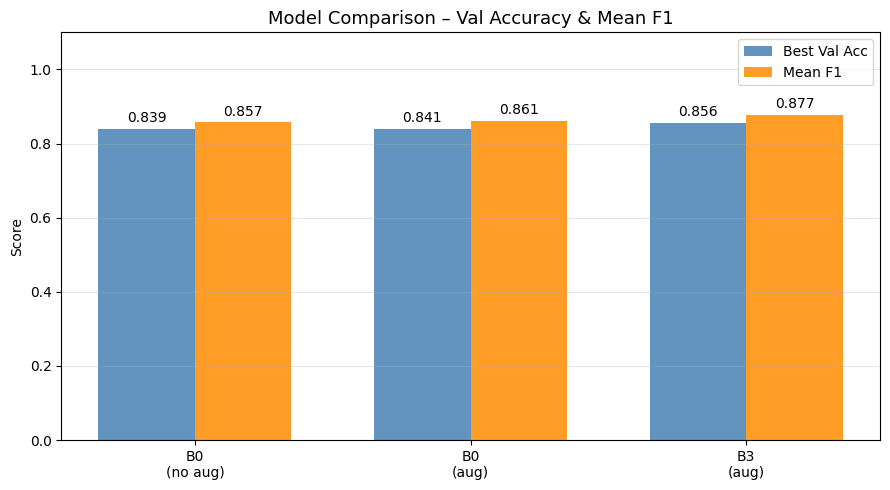

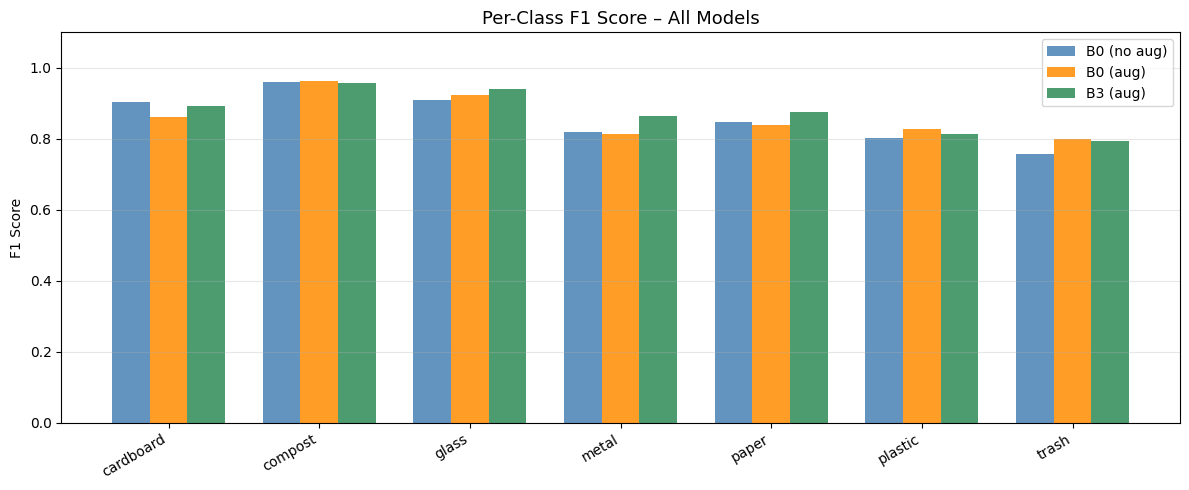

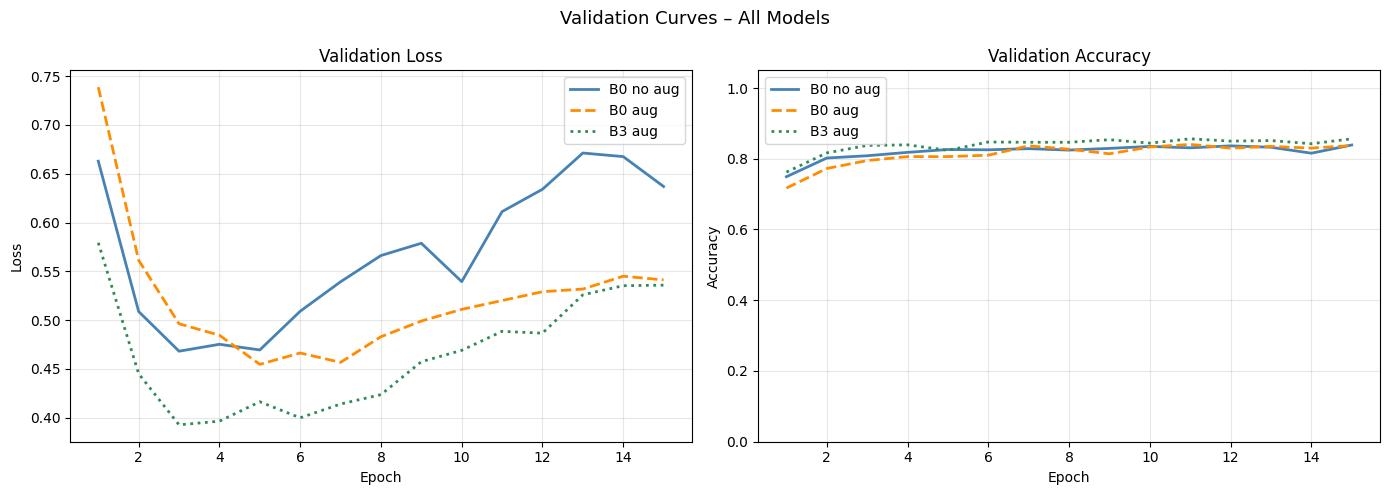

All comparison plots saved → /content/drive/MyDrive/ScrapNet/experiments/comparison


In [15]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

summaries  = [summary_b0_noaug, summary_b0_aug, summary_b3_aug]
exp_labels = ['B0\n(no aug)', 'B0\n(aug)', 'B3\n(aug)']

compare_dir = Path(OUTPUT_DIR) / 'comparison'
compare_dir.mkdir(exist_ok=True)

# ── Bar chart: Best Val Acc & Mean F1
val_accs = [s['best_val_acc'] for s in summaries]
mean_f1s = [s['mean_f1'] for s in summaries]
x = np.arange(len(exp_labels))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, val_accs, width, label='Best Val Acc', color='steelblue', alpha=0.85)
b2 = ax.bar(x + width/2, mean_f1s, width, label='Mean F1',      color='darkorange', alpha=0.85)
for bar in b1 + b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(exp_labels)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Model Comparison – Val Accuracy & Mean F1', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(compare_dir / 'model_comparison.png', dpi=300)
plt.show()

# ── Per-class F1
all_classes = list(summaries[0]['per_class_f1'].keys())
f1_matrix   = np.array([[s['per_class_f1'][c] for c in all_classes] for s in summaries])
x = np.arange(len(all_classes))
fig2, ax2 = plt.subplots(figsize=(12, 5))
colors = ['steelblue', 'darkorange', 'seagreen']
for i, (label, color) in enumerate(zip(exp_labels, colors)):
    ax2.bar(x + (i-1)*0.25, f1_matrix[i], width=0.25,
            label=label.replace('\n',' '), color=color, alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(all_classes, rotation=30, ha='right')
ax2.set_ylim(0, 1.1); ax2.set_ylabel('F1 Score')
ax2.set_title('Per-Class F1 Score – All Models', fontsize=13)
ax2.legend(); ax2.grid(axis='y', alpha=0.3)
fig2.tight_layout()
fig2.savefig(compare_dir / 'per_class_f1_comparison.png', dpi=300)
plt.show()

# ── Val curves overlay
fig3, axes = plt.subplots(1, 2, figsize=(14, 5))
histories   = [history_b0_noaug, history_b0_aug, history_b3_aug]
line_labels = ['B0 no aug', 'B0 aug', 'B3 aug']
styles = ['-', '--', ':']
for h, label, ls, col in zip(histories, line_labels, styles, colors):
    ep = range(1, len(h['val_loss']) + 1)
    axes[0].plot(ep, h['val_loss'], linestyle=ls, color=col, linewidth=2, label=label)
    axes[1].plot(ep, h['val_acc'],  linestyle=ls, color=col, linewidth=2, label=label)
axes[0].set_title('Validation Loss');    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
for ax in axes: ax.legend(); ax.grid(alpha=0.3)
fig3.suptitle('Validation Curves – All Models', fontsize=13)
fig3.tight_layout()
fig3.savefig(compare_dir / 'val_curves_overlay.png', dpi=300)
plt.show()
print(f'All comparison plots saved → {compare_dir}')

In [16]:
print(f"{'Experiment':<20} {'Best Val Acc':>12} {'Mean F1':>8}")
print('-' * 44)
for s in summaries:
    print(f"{s['experiment']:<20} {s['best_val_acc']:>12.4f} {s['mean_f1']:>8.4f}")

Experiment           Best Val Acc  Mean F1
--------------------------------------------
b0_no_aug                  0.8389   0.8572
b0_aug                     0.8405   0.8612
b3_aug                     0.8563   0.8766


## Step 6 · Confirm Everything Saved to Drive

In [17]:
import os
from pathlib import Path

exp_root = Path(OUTPUT_DIR)
print(f'Experiments saved at: {exp_root}\n')
if exp_root.exists():
    for root, dirs, files in os.walk(exp_root):
        dirs.sort(); files.sort()
        level  = root.replace(str(exp_root), '').count(os.sep)
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        for f in sorted(files):
            print(f'{indent}  {f}')
else:
    print('Output directory not found!')

Experiments saved at: /content/drive/MyDrive/ScrapNet/experiments

experiments/
  b0_aug/
    accuracy_curve.png
    classes.json
    classification_report.txt
    confusion_matrix.png
    confusion_matrix_normalized.png
    f1_scores.png
    history.json
    loss_curve.png
    model.pth
    summary.json
  b0_no_aug/
    accuracy_curve.png
    classes.json
    classification_report.txt
    confusion_matrix.png
    confusion_matrix_normalized.png
    f1_scores.png
    history.json
    loss_curve.png
    model.pth
    summary.json
  b3_aug/
    accuracy_curve.png
    classes.json
    classification_report.txt
    confusion_matrix.png
    confusion_matrix_normalized.png
    f1_scores.png
    history.json
    loss_curve.png
    model.pth
    summary.json
  comparison/
    model_comparison.png
    per_class_f1_comparison.png
    val_curves_overlay.png
